In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()
dfs = pd.read_csv("../data/features.csv", index_col="Time_[s]")
targets = pd.read_csv("../data/targets.csv", index_col=False)
# df = dfs[dfs["Experiment_ID"]==2].drop(columns=["Experiment_ID"])
# target = targets[targets["Experiment_ID"]==2].iloc[:, 2:]
col = "Angle[degree]ORDistance[mm]"

scaler = MinMaxScaler(feature_range=(0, 1))
targets[col] = scaler.fit_transform(targets[[col]])
dfs

,Experiment_ID,MACHINE_BEND-DIE_LATERAL_Max_Torque_[%],MACHINE_BEND-DIE_ROTATING_Max_Torque_[%],MACHINE_BEND-DIE_VERTICAL_Max_Torque_[%],MACHINE_CLAMP-DIE_LATERAL_Max_Torque_[%],MACHINE_COLLET_AXIAL_Max_Torque_[%],MACHINE_COLLET_ROTATING_Max_Torque_[%],MACHINE_MANDREL_AXIAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_LATERAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_LEFT_AXIAL_Max_Torque_[%],BEND-DIE_LATERAL_Movement_[mm],BEND-DIE_ROTATING_Angle_[°],BEND-DIE_VERTICAL_Movement_[mm],CLAMP-DIE_LATERAL_Movement_[mm],COLLET_AXIAL_Movement_[mm],MANDREL_AXIAL_Movement_[mm],PRESSURE-DIE_AXIAL_Movement_[mm],PRESSURE-DIE_LATERAL_Movement_[mm]
Time_[s],,,,,,,,,,,,,,,,,,
0.00,2,0.135068,0.817045,0.293651,0.436154,0.397692,0.107143,0.985937,0.757580,0.59375,0.999967,1.000000,0.456468,0.570124,0.000005,0.900879,0.000373,0.999849
0.05,2,0.135068,0.817045,0.285714,0.436154,0.397822,0.107143,0.985937,0.750271,0.59375,0.999967,1.000000,0.456468,0.570124,0.000004,0.900879,0.000373,0.999842
0.10,2,0.135068,0.817045,0.293651,0.436154,0.398065,0.107143,0.984375,0.698300,0.59375,0.999967,1.000000,0.456468,0.570124,0.000004,0.900879,0.000373,0.999540
0.15,2,0.136307,0.817045,0.293651,0.436154,0.397887,0.107143,0.985937,0.585460,0.62500,0.999967,1.000000,0.456468,0.570124,0.000005,0.900879,0.000373,0.998401
0.20,2,0.135068,0.817045,0.285714,0.436154,0.397741,0.107143,0.984375,0.476972,0.65625,0.999967,1.000000,0.456468,0.570124,0.000002,0.900879,0.000373,0.997003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86.30,314,0.074349,0.875032,0.285714,0.419720,0.414831,0.785714,0.926562,0.793701,0.43750,0.000007,0.997979,0.456468,0.000004,0.984199,0.094463,0.000373,0.999849
86.35,314,0.074349,0.872084,0.293651,0.419720,0.415124,0.785714,0.928125,0.793552,0.43750,0.000007,0.998670,0.456468,0.000004,0.984199,0.094463,0.000373,0.999849
86.40,314,0.074349,0.874473,0.285714,0.419720,0.415188,0.785714,0.926562,0.793404,0.43750,0.000007,0.999223,0.456468,0.000004,0.984199,0.094463,0.000373,0.999849


In [2]:
# import numpy as np

# # Keep features with variance above a threshold
# variance_threshold = 0.09
# dfs = dfs.loc[:, dfs.var() > variance_threshold]

In [12]:
groups_y = []
max_len_y = targets.groupby("Experiment_ID").size().max()
num_target_features = targets.shape[1] - 1  # exclude Experiment_ID

for exp_id, group in targets.groupby("Experiment_ID"):
    values = group.drop(columns=["Experiment_ID"]).values  # (len_group, num_target_features)
    
    # Pad with NaN
    padded = np.full((max_len_y, num_target_features), np.nan)
    padded[:values.shape[0], :] = values
    groups_y.append(padded)

# Final y: (num_experiments, max_len, num_target_features)
y = np.array(groups_y, dtype=float)

# Replace NaN with 0
Y = np.nan_to_num(y, nan=0.0)



groups = []
max_len = dfs.groupby("Experiment_ID").size().max()  # longest experiment
num_features = dfs.shape[1] - 1  # exclude Experiment_ID

for exp_id, group in dfs.groupby("Experiment_ID"):
    features = group.drop(columns=["Experiment_ID"]).values
    
    # Pad with NaN (or zeros) to match max_len
    padded = np.full((max_len, num_features), np.nan)  
    padded[:features.shape[0], :] = features
    groups.append(padded)


X = np.array(groups, dtype=float)
time_series_data = np.nan_to_num(X, nan=0.0)[:,:,:]
Y = np.nan_to_num(y, nan=0.0)[:,:,1:-1]
print("Shape:", time_series_data.shape, Y.shape)  

Shape: (100, 1743, 17) (100, 47, 4)


In [13]:
from utils.clustering_utils import cluster_time_series_subsequences, plot_k_selection

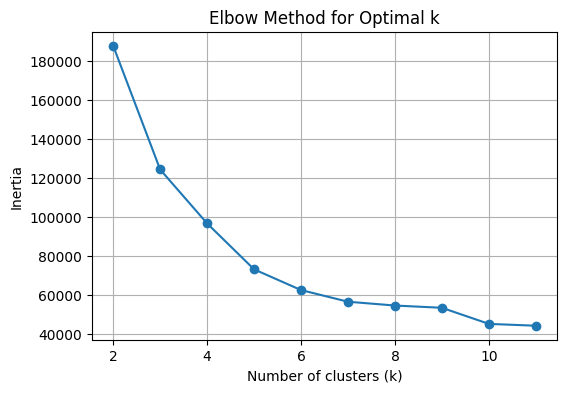

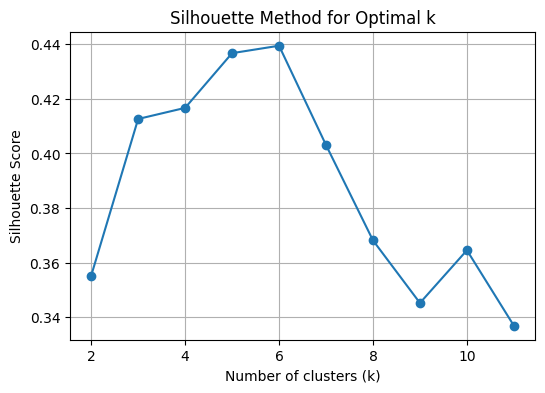

In [5]:
inertias, scores = plot_k_selection(time_series_data, series_idx=50, window_size=10, k_range=range(2, 12))

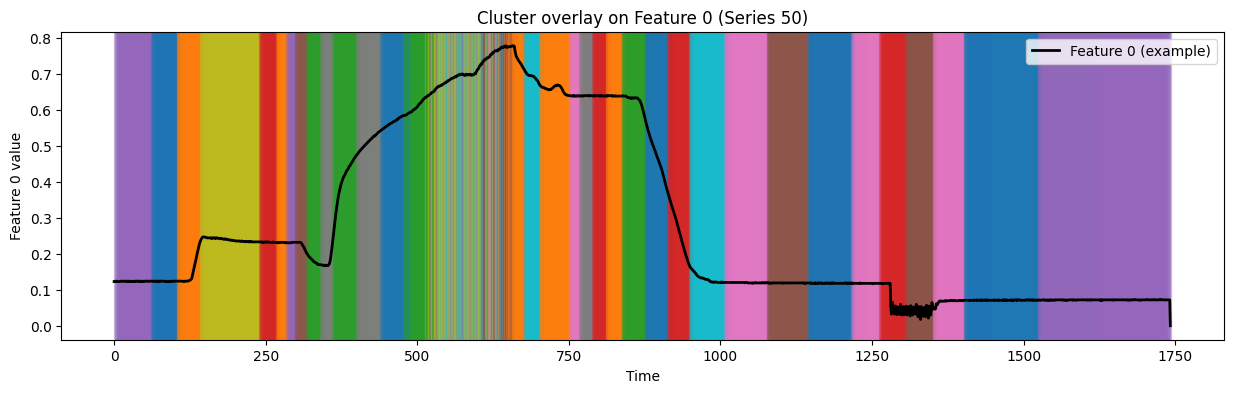

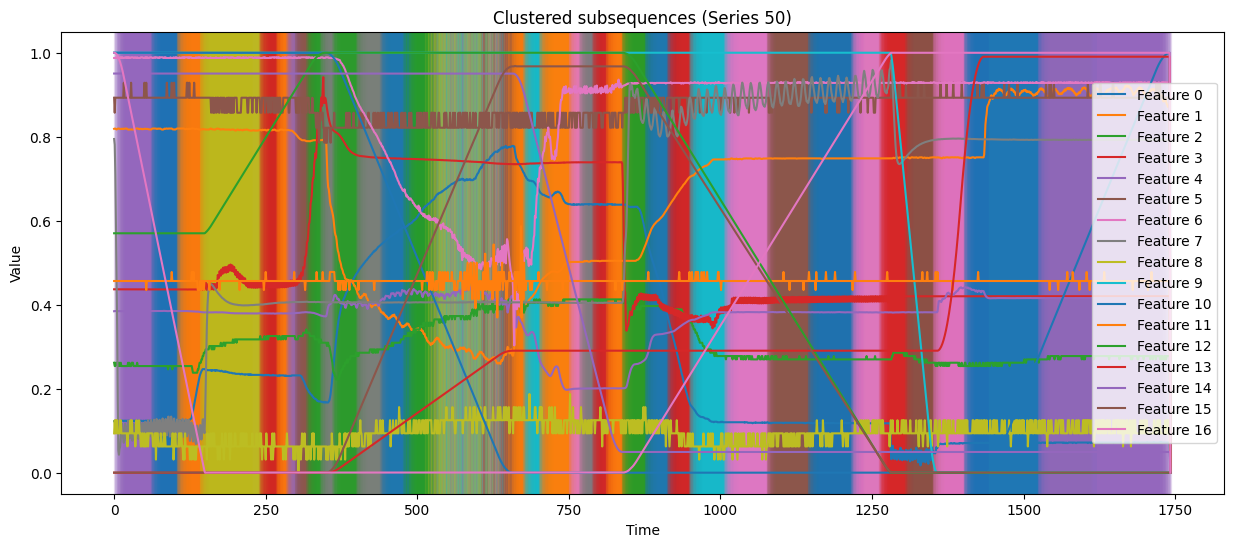

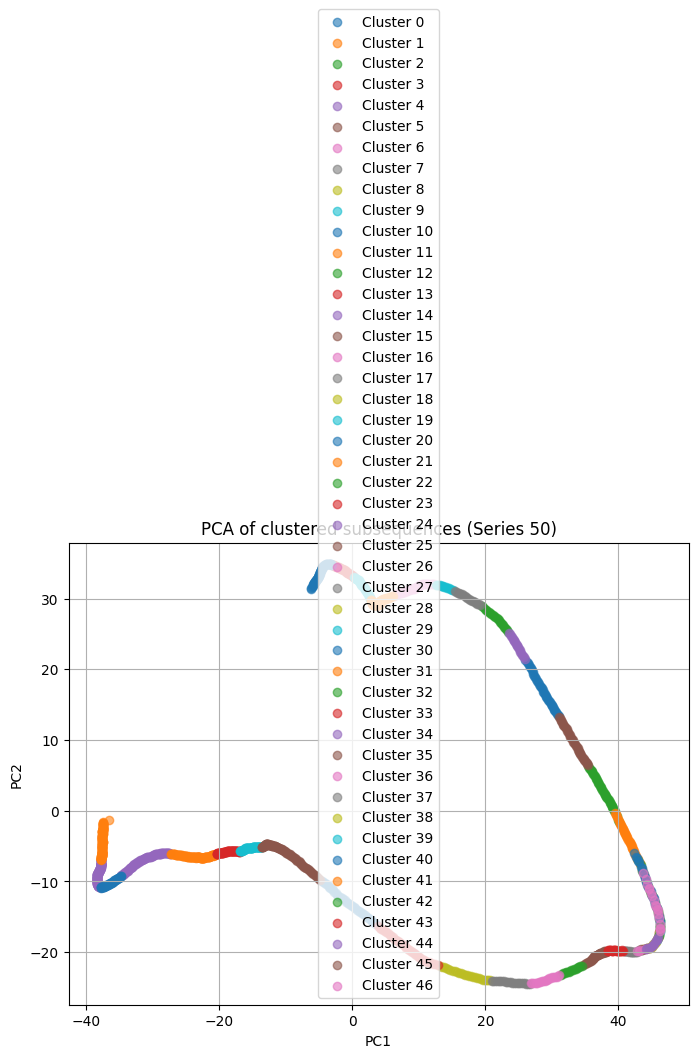

,Unnamed: 0,Experiment_ID,Angle[degree]ORDistance[mm],Secondary-axis [mm],Main-axis [mm],Out-of-roundness [-],Collapse [mm]
2307,3642,82,0.000000,0.361117,0.691183,0.276498,0.700444
2308,3643,82,0.022036,0.346625,0.653351,0.310932,0.660135
2309,3644,82,0.044072,0.331950,0.608984,0.351982,0.612864
2310,3645,82,0.066108,0.316170,0.554104,0.403445,0.554391
2311,3646,82,0.088145,0.300404,0.494382,0.459856,0.490759
2312,3647,82,0.110181,0.292409,0.458658,0.494014,0.452695
2313,3648,82,0.132217,0.290554,0.448731,0.503612,0.442118
2314,3649,82,0.154253,0.297864,0.453197,0.501164,0.446877
2315,3650,82,0.176289,0.305733,0.462204,0.494243,0.456473
2316,3651,82,0.198325,0.303756,0.473320,0.482324,0.468317


In [15]:
experiment_index = 50
labels, kmeans, _ = cluster_time_series_subsequences(
    time_series_data,
    series_idx=experiment_index,
    window_size=100,
    n_clusters=47
)
idx = targets["Experiment_ID"].unique()[experiment_index]
target = targets[targets["Experiment_ID"]==idx]
target